In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from lightgbm import LGBMClassifier ## Add for XGBoost, CatBoost as well

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

import optuna
from optuna.samplers import TPESampler

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv
/kaggle/input/tabular-playground-series-nov-2021/train.csv
/kaggle/input/tabular-playground-series-nov-2021/test.csv


In [2]:
df_train = pd.read_csv('../input/tabular-playground-series-nov-2021/train.csv')
df_test = pd.read_csv('../input/tabular-playground-series-nov-2021/test.csv')
submission = pd.read_csv('../input/tabular-playground-series-nov-2021/sample_submission.csv')

### Let's have an Overview of the Data

In [3]:
print(df_train.info())
print('*****')
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Columns: 102 entries, id to target
dtypes: float64(100), int64(2)
memory usage: 466.9 MB
None
*****
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540000 entries, 0 to 539999
Columns: 101 entries, id to f99
dtypes: float64(100), int64(1)
memory usage: 416.1 MB
None


In [4]:
print(df_train.shape)
print(df_test.shape)

(600000, 102)
(540000, 101)


In [5]:
features = [col for col in df_train.columns if 'f' in col]

In [6]:
print(features)

['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'f35', 'f36', 'f37', 'f38', 'f39', 'f40', 'f41', 'f42', 'f43', 'f44', 'f45', 'f46', 'f47', 'f48', 'f49', 'f50', 'f51', 'f52', 'f53', 'f54', 'f55', 'f56', 'f57', 'f58', 'f59', 'f60', 'f61', 'f62', 'f63', 'f64', 'f65', 'f66', 'f67', 'f68', 'f69', 'f70', 'f71', 'f72', 'f73', 'f74', 'f75', 'f76', 'f77', 'f78', 'f79', 'f80', 'f81', 'f82', 'f83', 'f84', 'f85', 'f86', 'f87', 'f88', 'f89', 'f90', 'f91', 'f92', 'f93', 'f94', 'f95', 'f96', 'f97', 'f98', 'f99']


## Observing the test data

<AxesSubplot:xlabel='target', ylabel='count'>

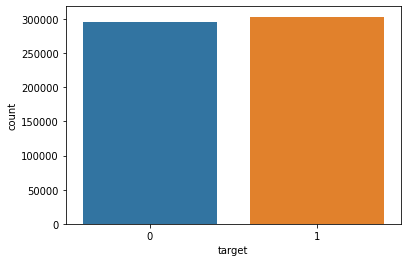

In [7]:
import seaborn as sns

sns.countplot(x = 'target', data = df_train)

## Conclusion
The distribution of data with target = 0 and target = 1 made are the same. This is one less thing to worry about :)

## Observing the distribution of data in the train and test set

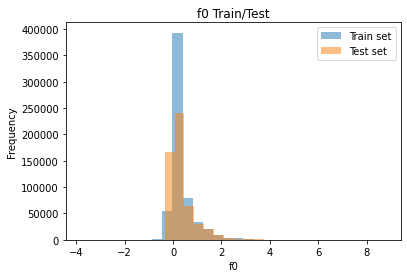

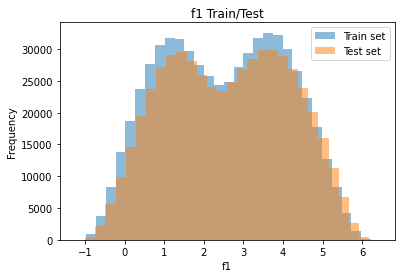

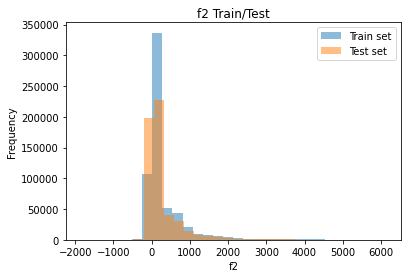

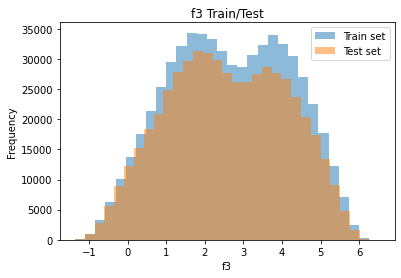

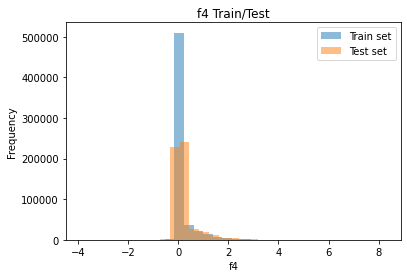

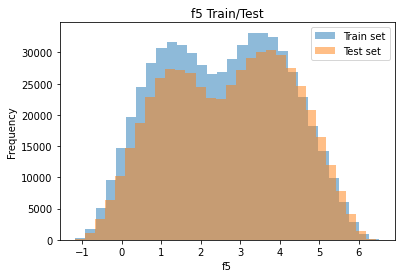

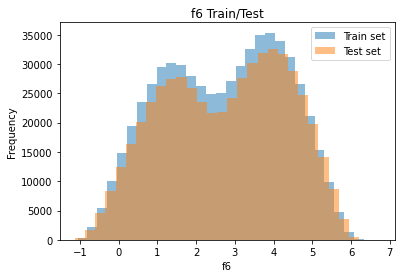

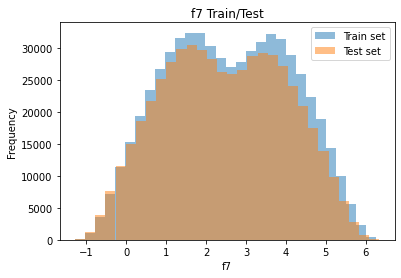

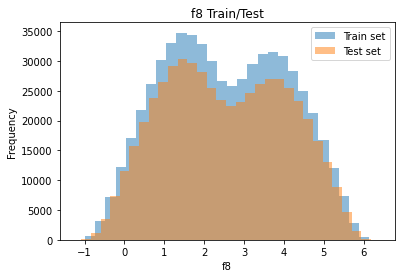

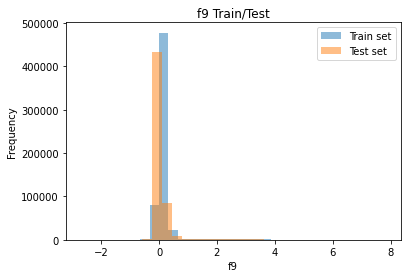

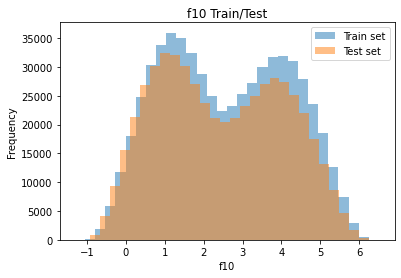

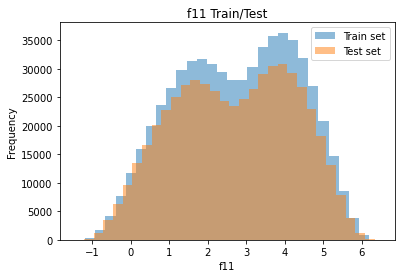

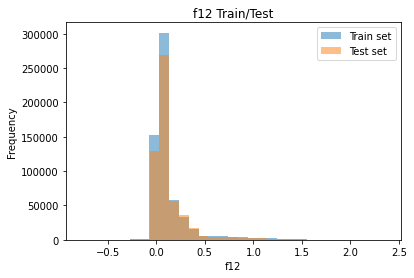

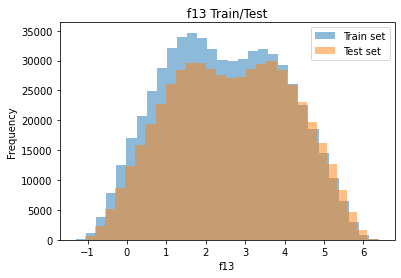

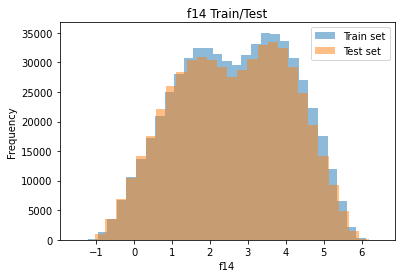

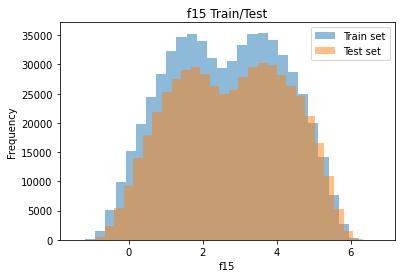

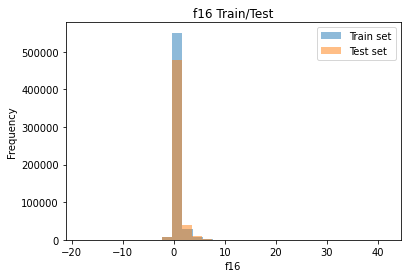

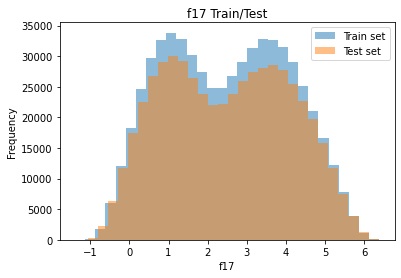

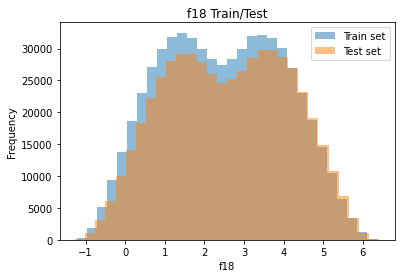

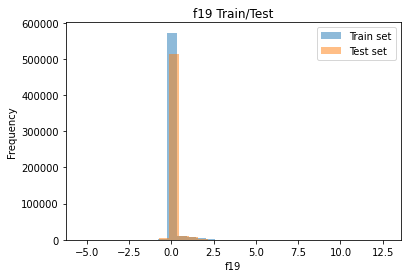

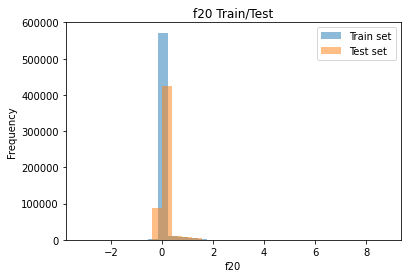

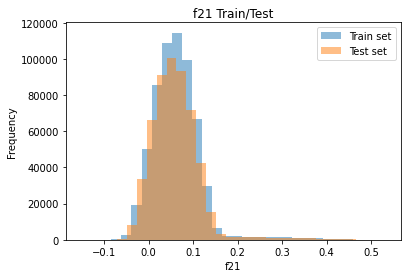

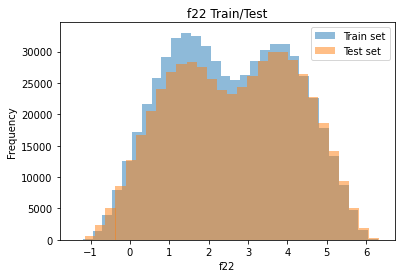

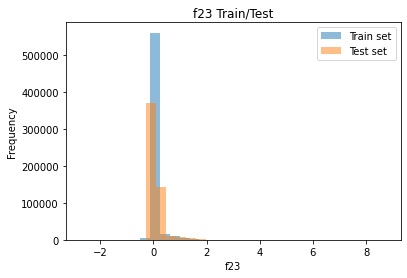

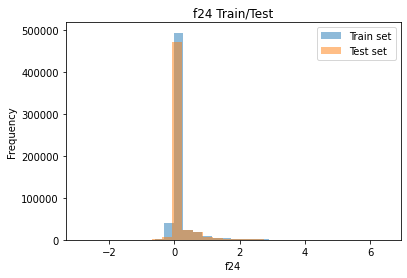

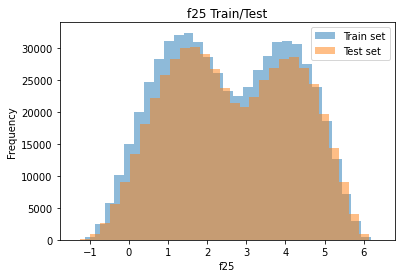

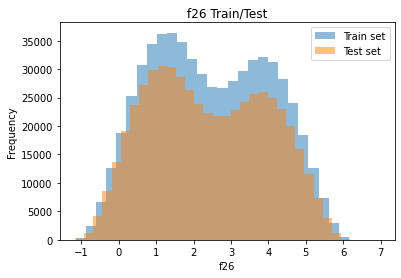

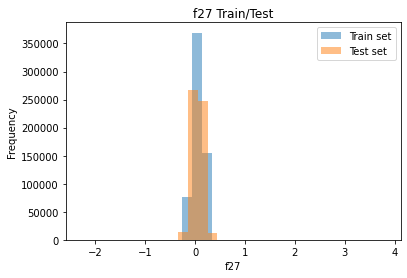

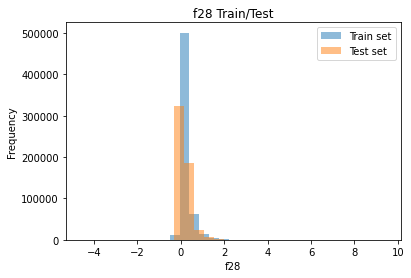

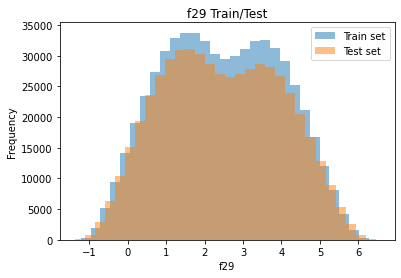

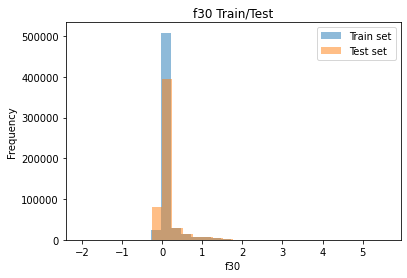

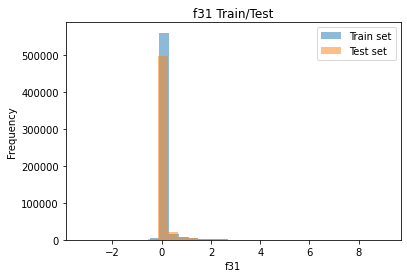

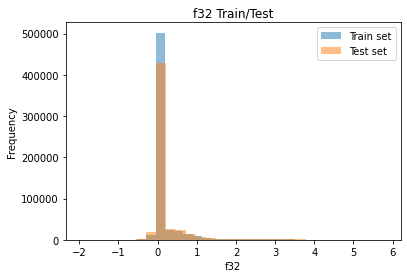

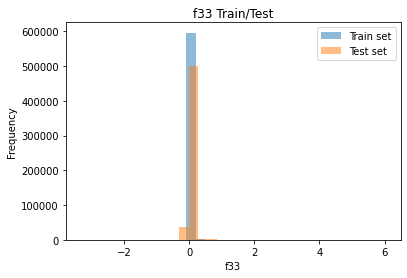

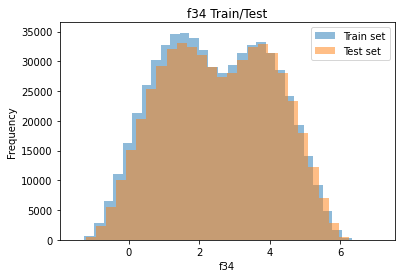

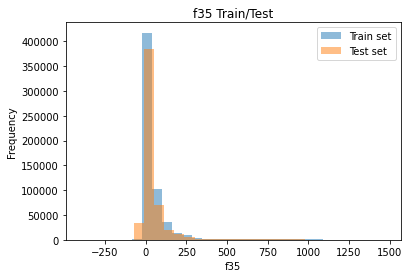

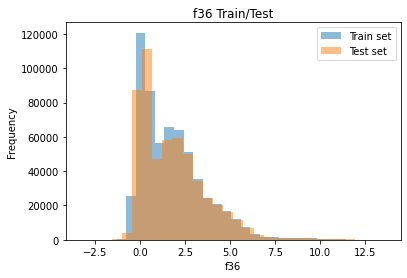

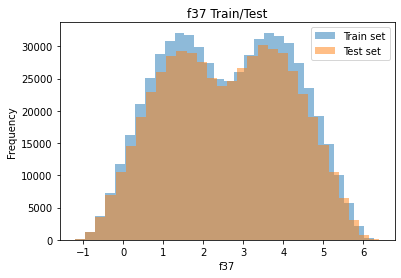

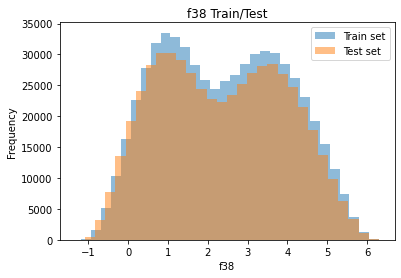

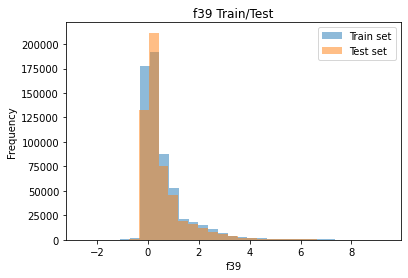

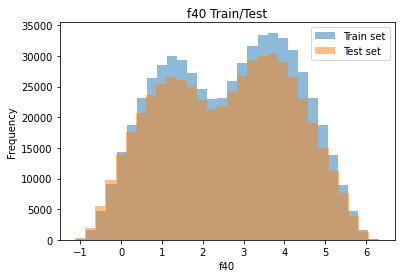

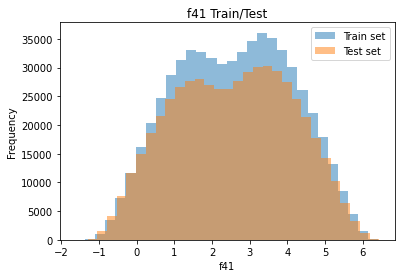

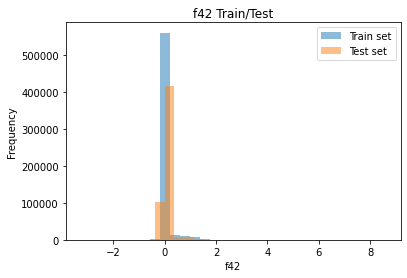

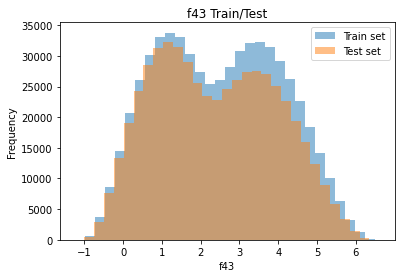

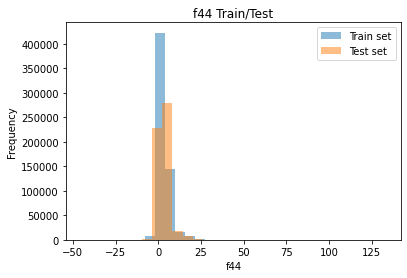

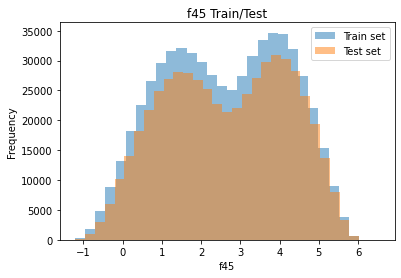

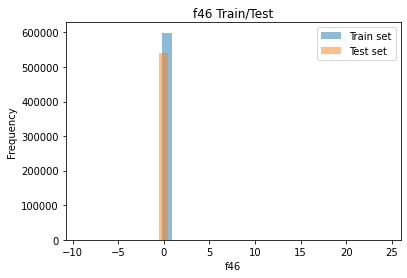

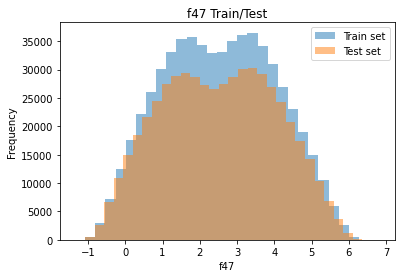

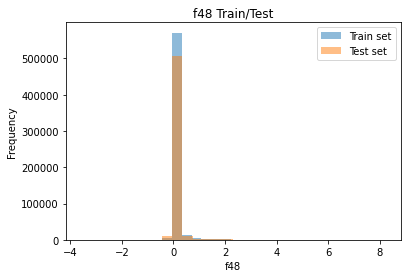

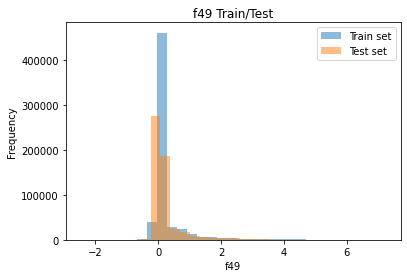

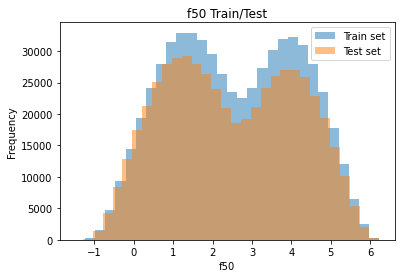

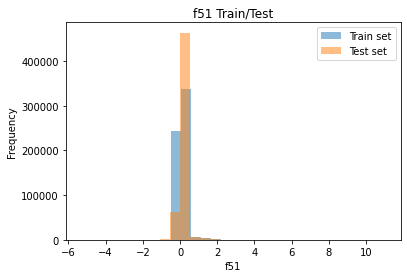

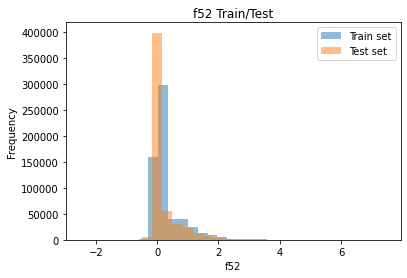

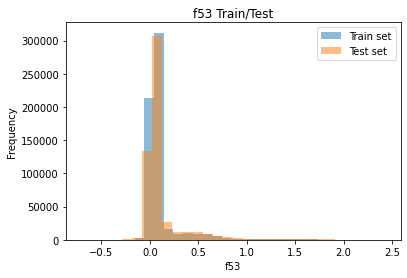

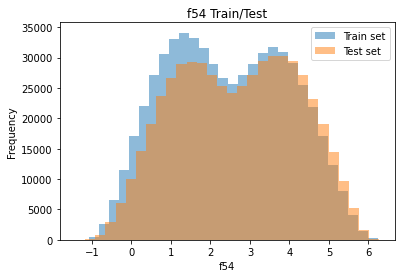

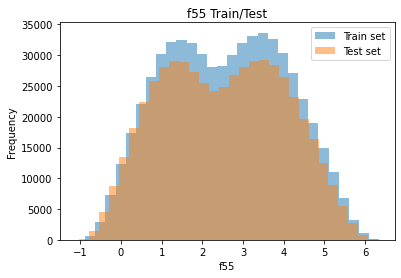

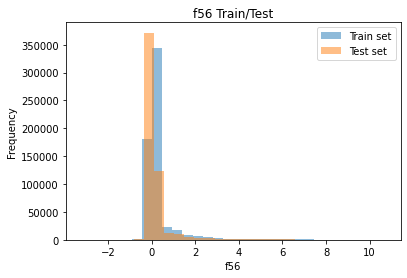

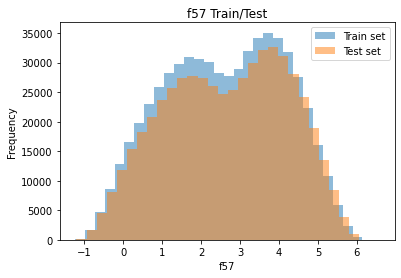

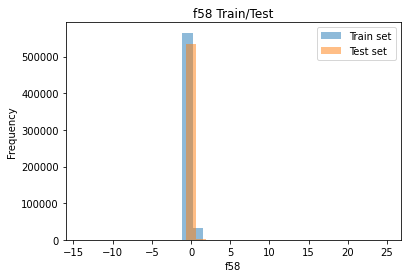

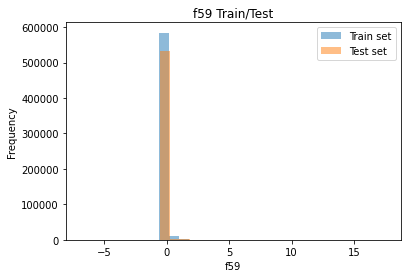

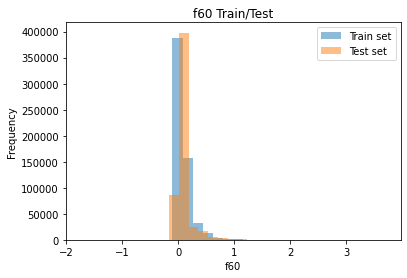

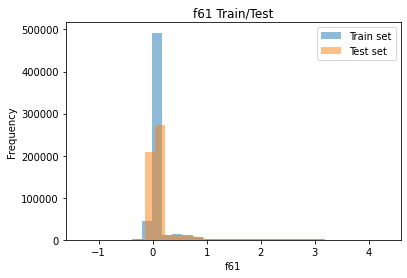

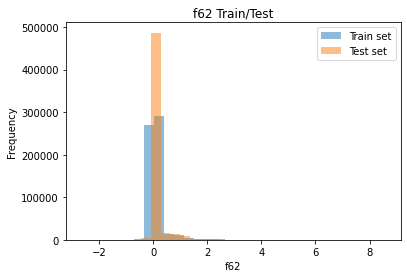

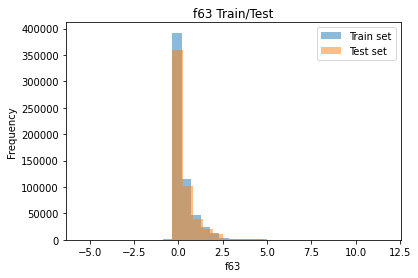

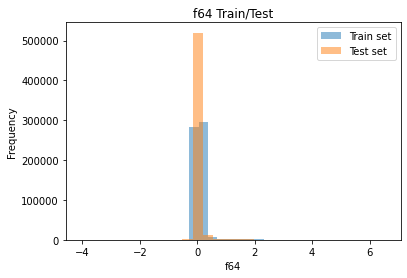

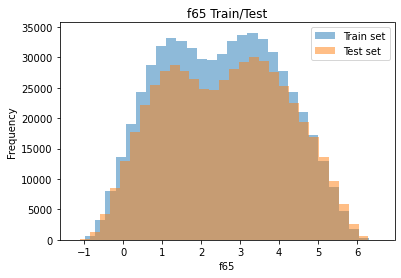

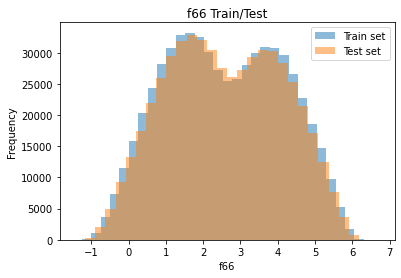

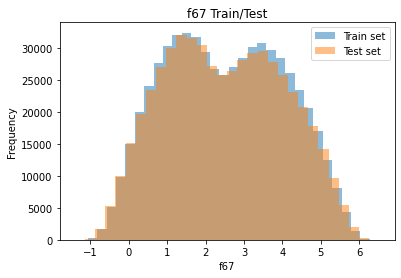

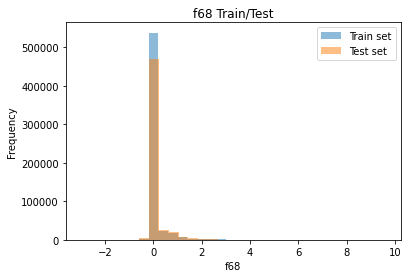

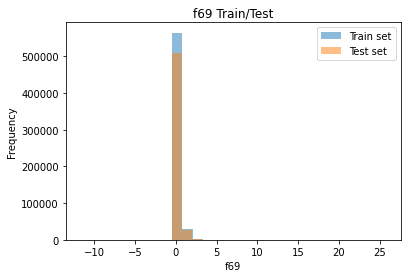

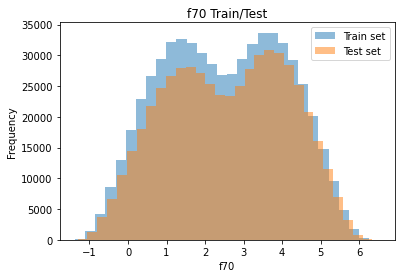

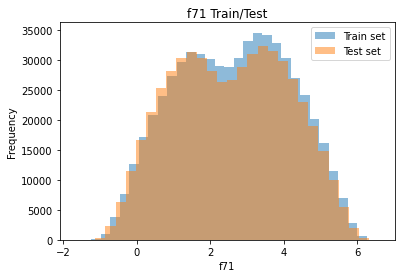

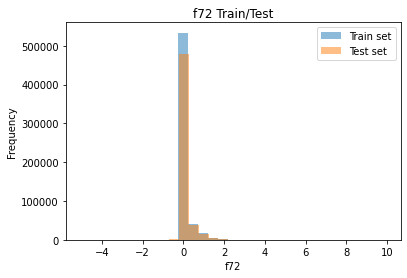

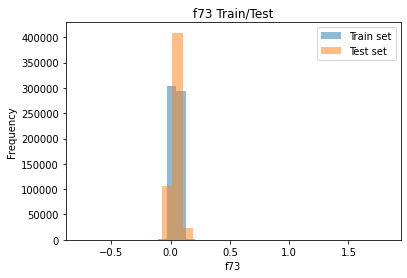

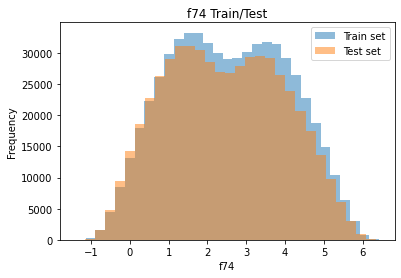

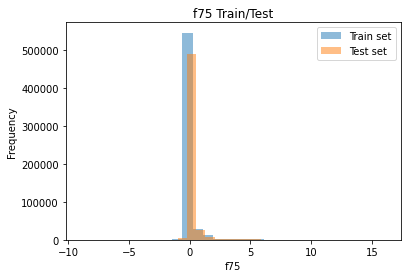

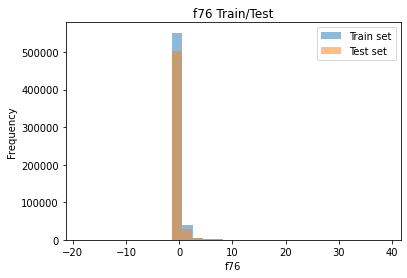

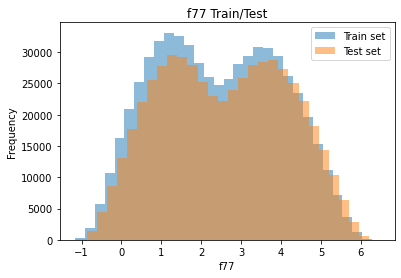

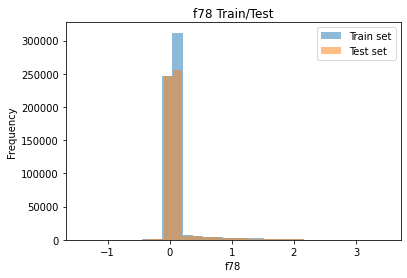

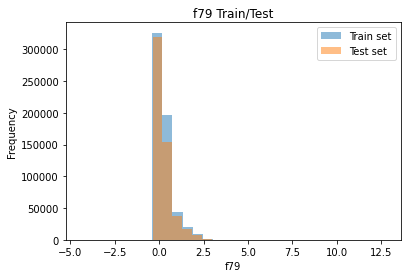

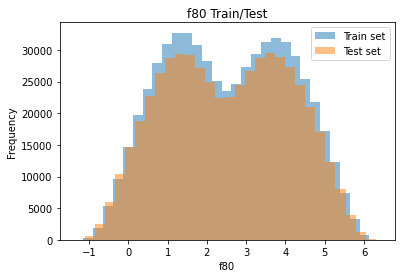

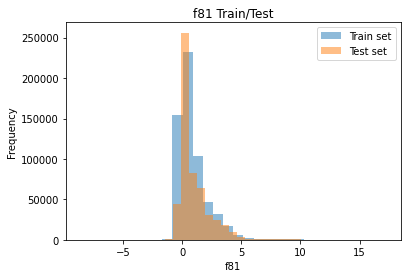

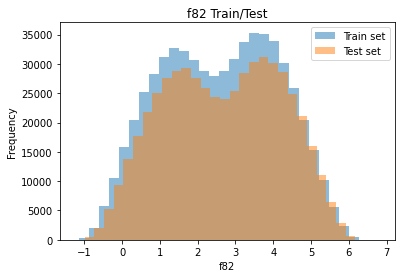

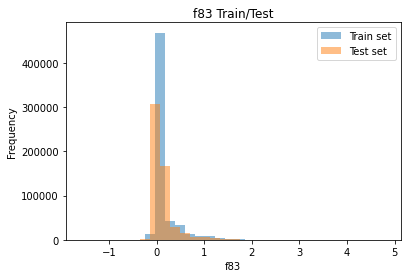

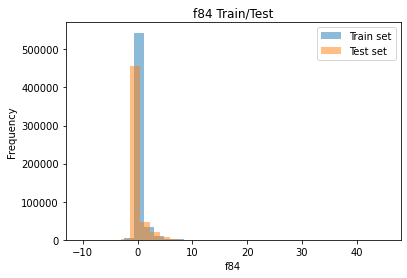

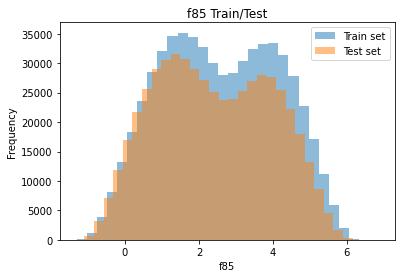

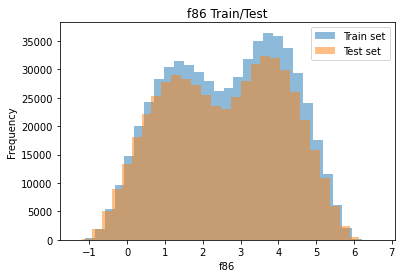

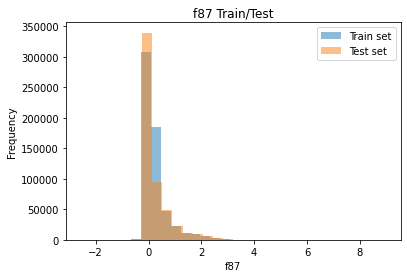

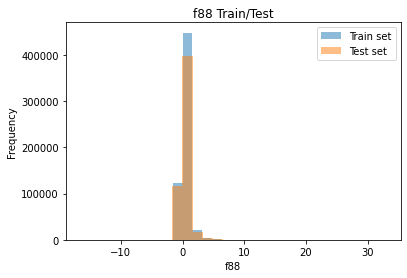

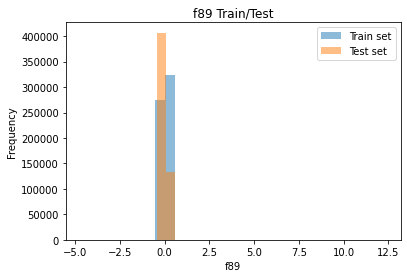

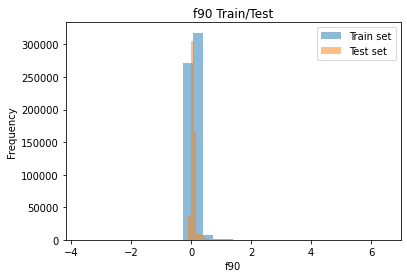

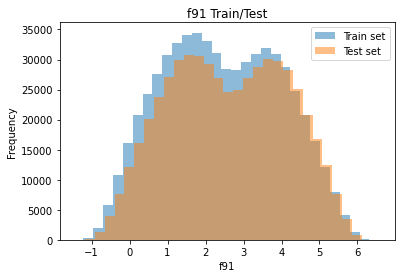

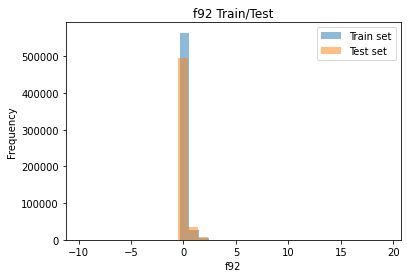

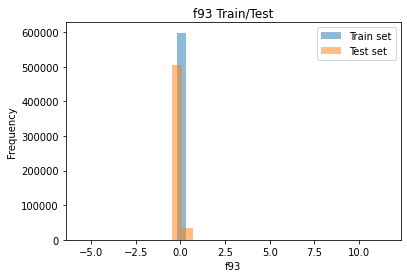

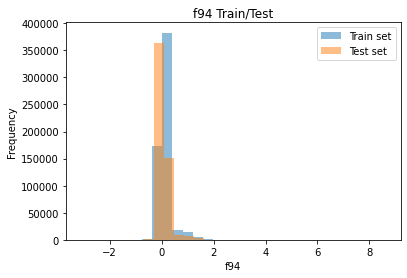

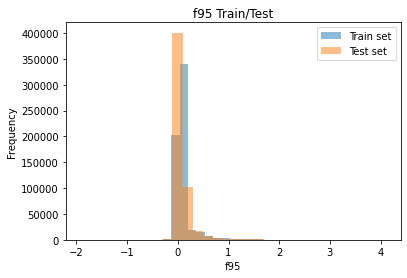

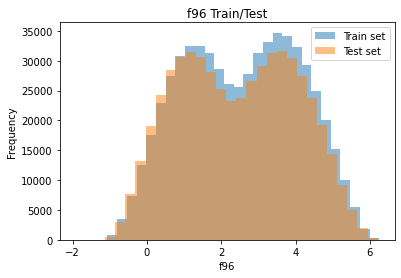

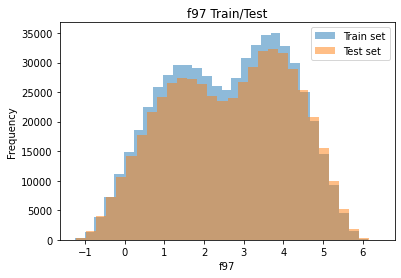

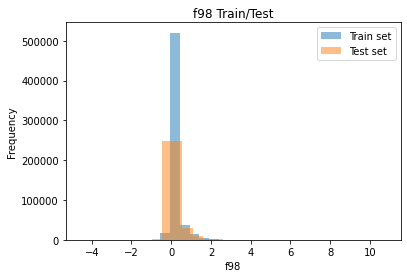

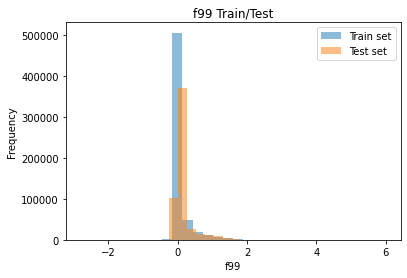

In [8]:
import matplotlib.pyplot as plt

for idx, feature in enumerate(features):
    plt.hist(df_train[feature], bins=30, alpha=0.5, label='Train set')
    plt.hist(df_test[feature], bins=30, alpha=0.5, label='Test set')
    plt.title(feature + " Train/Test")
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    plt.legend()
    plt.show()

## Conclusion
The train and test data distribution are similar. This is great!!!

In [9]:
print(df_train[features].isna().sum().sum())
print(df_test[features].isna().sum().sum())

0
0


No missing values in train and test data. That is one less thing to worry about

In [10]:
X = df_train[features].copy()
y = df_train['target'].copy()

x_test = df_test[features].copy()

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[features] = scaler.fit_transform(X[features])
x_test[features] = scaler.transform(x_test[features])

### Implementing LGBM Classifier

In [12]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

### Hyperparameter Optimization Usinf optuna

def lgb_objective(trial):
    params = {
        'boosting_type': 'gbdt',
        'objective': 'binary',
        'n_estimators': trial.suggest_int("n_estimators", 64, 8192),
        'learning_rate': trial.suggest_float("learning_rate", 1e-3, 0.25, log=True),
        'num_leaves': trial.suggest_int("num_leaves", 20, 3000),
        'max_depth': trial.suggest_int("max_depth", 3, 12),
        'feature_fraction': trial.suggest_float("feature_fraction", 0.1, 1.0),
        'min_gain_to_split' : trial.suggest_int('min_gain_to_split', 0, 15),
        'min_data_in_leaf' : trial.suggest_int("min_data_in_leaf", 100, 1000),
        'lambda_l1': trial.suggest_loguniform("lambda_l1", 1e-8, 100.0),
        'lambda_l2': trial.suggest_loguniform("lambda_l2", 1e-8, 100.0),
        'bagging_fraction' : trial.suggest_float("bagging_fraction", 0, 0.8),
        'bagging_freq' : trial.suggest_int("bagging_freq", 1, 100),
        'seed': 42,
        'deterministic': True,
        'metric' : 'auc',
        'verbose':-1
    }
    
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.3, random_state = 42)
    
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train,
             eval_set = [(X_train, y_train), (X_val, y_val)],
              early_stopping_rounds = 100,
              eval_metric = 'auc',
              verbose = 0
            )
    pred_val = model.predict(X_val)
    
    return roc_auc_score(y_val, pred_val)

In [13]:
sampler = TPESampler(seed = 42)
study = optuna.create_study(study_name = 'lgbm_hpo',direction = 'maximize',sampler = sampler)

study.optimize(lgb_objective, n_trials = 10)

[I 2021-11-18 08:20:53,483] A new study created in memory with name: lgbm_hpo


[LightGBM] [Warning] bagging_fraction is set=0.5664580622368364, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5664580622368364
[LightGBM] [Warning] lambda_l1 is set=4.589458612326471, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.589458612326471
[LightGBM] [Warning] min_gain_to_split is set=2, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=2
[LightGBM] [Warning] min_data_in_leaf is set=152, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=152
[LightGBM] [Warning] feature_fraction is set=0.24041677639819287, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.24041677639819287
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] lambda_l2 is set=0.010260065124896791, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.010260065124896791


[I 2021-11-18 08:21:31,261] Trial 0 finished with value: 0.698395370364127 and parameters: {'n_estimators': 3108, 'learning_rate': 0.19043899115982607, 'num_leaves': 2202, 'max_depth': 8, 'feature_fraction': 0.24041677639819287, 'min_gain_to_split': 2, 'min_data_in_leaf': 152, 'lambda_l1': 4.589458612326471, 'lambda_l2': 0.010260065124896791, 'bagging_fraction': 0.5664580622368364, 'bagging_freq': 3}. Best is trial 0 with value: 0.698395370364127.


[LightGBM] [Warning] bagging_fraction is set=0.4894823157779036, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4894823157779036
[LightGBM] [Warning] lambda_l1 is set=0.00020866527711063722, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.00020866527711063722
[LightGBM] [Warning] min_gain_to_split is set=4, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=4
[LightGBM] [Warning] min_data_in_leaf is set=572, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=572
[LightGBM] [Warning] feature_fraction is set=0.2650640588680905, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2650640588680905
[LightGBM] [Warning] bagging_freq is set=14, subsample_freq=0 will be ignored. Current value: bagging_freq=14
[LightGBM] [Warning] lambda_l2 is set=8.171304639059403e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=8.171304639059403e-06


[I 2021-11-18 08:23:02,633] Trial 1 finished with value: 0.7157311201876171 and parameters: {'n_estimators': 7948, 'learning_rate': 0.09911685499416945, 'num_leaves': 652, 'max_depth': 4, 'feature_fraction': 0.2650640588680905, 'min_gain_to_split': 4, 'min_data_in_leaf': 572, 'lambda_l1': 0.00020866527711063722, 'lambda_l2': 8.171304639059403e-06, 'bagging_fraction': 0.4894823157779036, 'bagging_freq': 14}. Best is trial 1 with value: 0.7157311201876171.


...

[I 2021-11-18 08:36:24,781] Trial 7 finished with value: 0.7020743711000818 and parameters: {'n_estimators': 665, 'learning_rate': 0.007237345608771641, 'num_leaves': 365, 'max_depth': 11, 'feature_fraction': 0.6609683141448022, 'min_gain_to_split': 5, 'min_data_in_leaf': 157, 'lambda_l1': 1.2877252667142128e-05, 'lambda_l2': 1.785801651522147e-05, 'bagging_fraction': 0.5836849426704512, 'bagging_freq': 64}. Best is trial 2 with value: 0.7181326147543577.


[LightGBM] [Warning] bagging_fraction is set=0.3420328146868397, subsample=1.0 will be ignored. Current value: bagging_fraction=0.3420328146868397
[LightGBM] [Warning] lambda_l1 is set=0.0008668739724852811, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0008668739724852811
[LightGBM] [Warning] min_gain_to_split is set=8, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=8
[LightGBM] [Warning] min_data_in_leaf is set=794, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=794
[LightGBM] [Warning] feature_fraction is set=0.7847065437552077, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7847065437552077
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] lambda_l2 is set=0.0016878284140548435, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0016878284140548435


[I 2021-11-18 08:42:15,256] Trial 8 finished with value: 0.7200854220543424 and parameters: {'n_estimators': 7276, 'learning_rate': 0.013562603384785458, 'num_leaves': 376, 'max_depth': 10, 'feature_fraction': 0.7847065437552077, 'min_gain_to_split': 8, 'min_data_in_leaf': 794, 'lambda_l1': 0.0008668739724852811, 'lambda_l2': 0.0016878284140548435, 'bagging_fraction': 0.3420328146868397, 'bagging_freq': 3}. Best is trial 8 with value: 0.7200854220543424.


[LightGBM] [Warning] bagging_fraction is set=0.18303853239329798, subsample=1.0 will be ignored. Current value: bagging_fraction=0.18303853239329798
[LightGBM] [Warning] lambda_l1 is set=0.00012700745988983495, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.00012700745988983495
[LightGBM] [Warning] min_gain_to_split is set=14, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=14
[LightGBM] [Warning] min_data_in_leaf is set=324, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=324
[LightGBM] [Warning] feature_fraction is set=0.5577136220482325, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5577136220482325
[LightGBM] [Warning] bagging_freq is set=8, subsample_freq=0 will be ignored. Current value: bagging_freq=8
[LightGBM] [Warning] lambda_l2 is set=0.3593448171877907, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.3593448171877907


[I 2021-11-18 08:44:21,686] Trial 9 finished with value: 0.6588404734866705 and parameters: {'n_estimators': 941, 'learning_rate': 0.0011895023429469723, 'num_leaves': 1917, 'max_depth': 6, 'feature_fraction': 0.5577136220482325, 'min_gain_to_split': 14, 'min_data_in_leaf': 324, 'lambda_l1': 0.00012700745988983495, 'lambda_l2': 0.3593448171877907, 'bagging_fraction': 0.18303853239329798, 'bagging_freq': 8}. Best is trial 8 with value: 0.7200854220543424.


In [14]:
lgbmparams = study.best_params

In [15]:
RANDOM_SEED = 42
n_splits = 5
skf = StratifiedKFold(n_splits = n_splits, shuffle = True, random_state = RANDOM_SEED)

test_preds_lgb = []
mean_auc = 0

model = LGBMClassifier(**lgbmparams)
best_lgb_model = None
best_roc_score_lgb = 0

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.loc[train_idx], X.loc[val_idx]
    y_train, y_val = y.loc[train_idx], y.loc[val_idx]
    
    model.fit(X_train, y_train,
             verbose = 0,
             eval_set = [(X_val, y_val)],
             eval_metric = 'auc',
             early_stopping_rounds = 100)
   
    y_pred = model.predict(X_val)
    score = roc_auc_score(y_val, y_pred)
    mean_auc += score
    
    
    if score>best_roc_score_lgb:
        best_roc_score_lgb = score
        best_lgb_model = model
    
    print(f"Fold {fold}'s score: {score}")
        
    test_preds_lgb.append(model.predict(x_test))

print("==========================================")
print(f"Mean auc of all folds: {mean_auc / n_splits}")

[LightGBM] [Warning] bagging_fraction is set=0.3420328146868397, subsample=1.0 will be ignored. Current value: bagging_fraction=0.3420328146868397
[LightGBM] [Warning] lambda_l1 is set=0.0008668739724852811, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0008668739724852811
[LightGBM] [Warning] min_gain_to_split is set=8, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=8
[LightGBM] [Warning] min_data_in_leaf is set=794, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=794
[LightGBM] [Warning] feature_fraction is set=0.7847065437552077, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7847065437552077
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] lambda_l2 is set=0.0016878284140548435, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0016878284140548435
Fold 0's score: 0.7186455273359933
[LightGBM] [Warning] bagging_frac

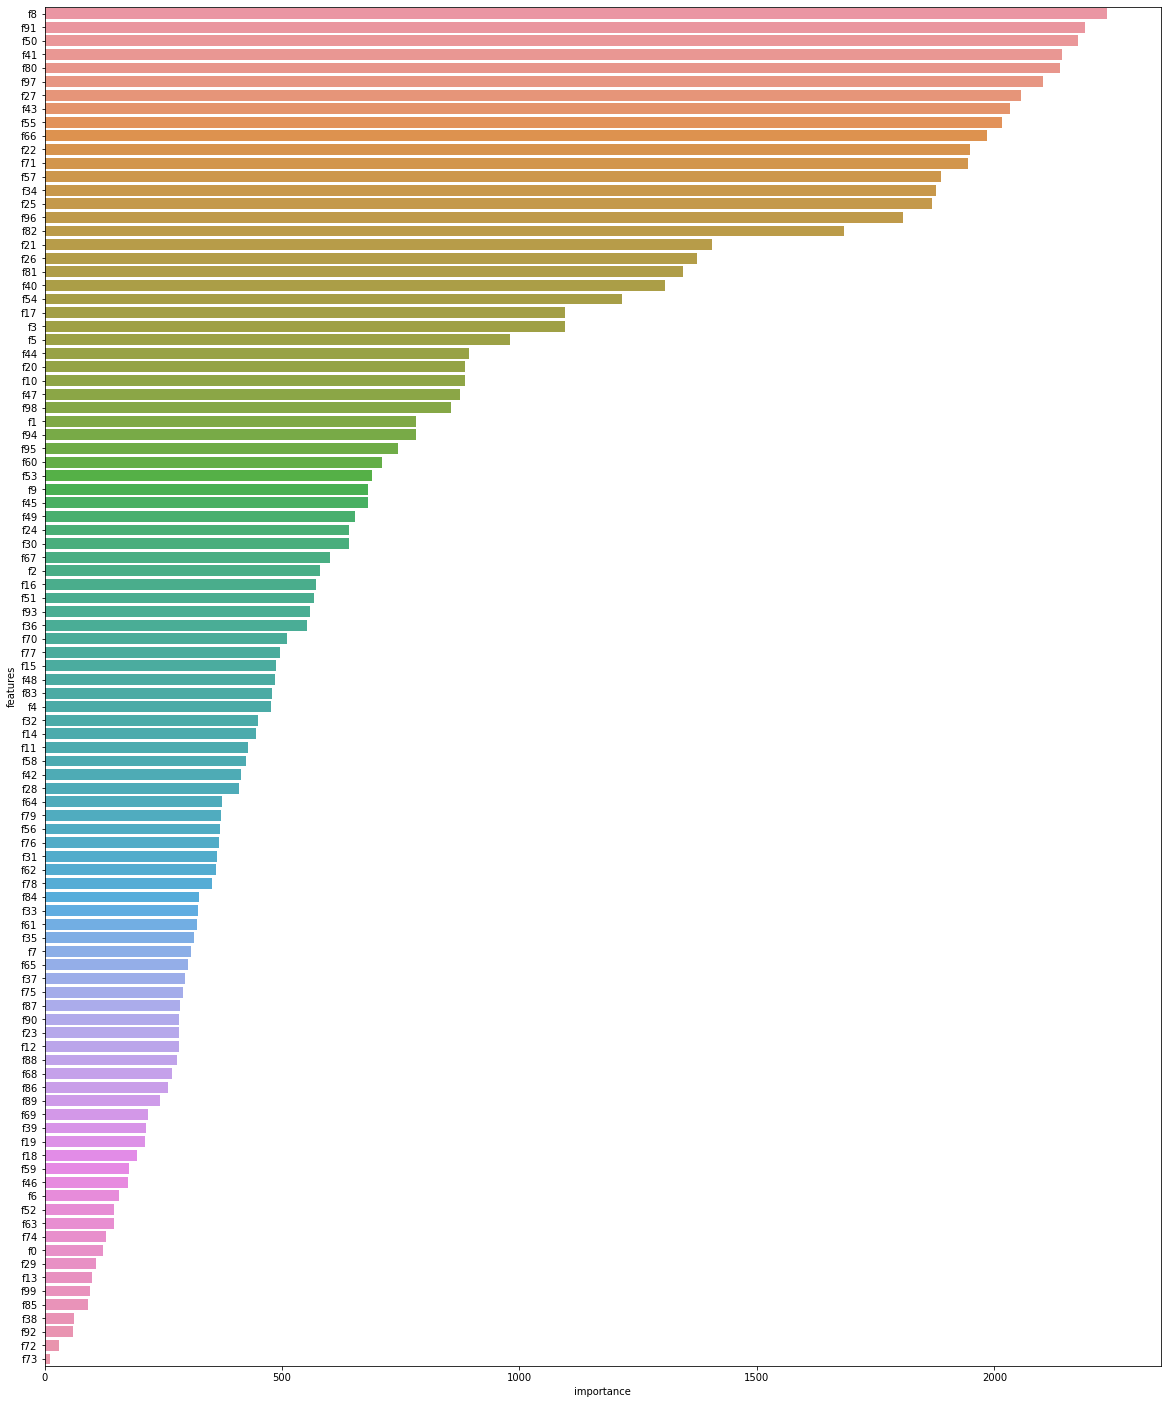

In [16]:
feature_impt=pd.DataFrame()
feature_impt['features']=best_lgb_model.feature_name_
feature_impt['importance']=best_lgb_model.feature_importances_

feature_impt.sort_values(by=['importance'],inplace=True,ascending=False)
plt.figure(figsize = (20,25))
sns.barplot(x=feature_impt['importance'],y=feature_impt['features'],data=feature_impt);

In [17]:
#final_lgb = pd.DataFrame()
#final_lgb['id'] = df_test['id']
#final_lgb['target'] = np.mean(test_preds_lgb, axis = 0)

In [18]:
#final_lgb.to_csv('final_lgb', index=False)

### Implementing XGB Classifier

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import xgboost as xgb

def xgb_objective(trial):
    params = {
        'boosting_type': 'gbtree',
        'learning_rate': trial.suggest_float("learning_rate", 1e-3, 0.25, log=True),
        'verbose':0,
        'gamma':trial.suggest_float("gamma", 1.0, 10),
        'max_depth': trial.suggest_int("max_depth", 3, 12),
        'lambda' : trial.suggest_loguniform("lambda", 1e-8, 100.0),
        'alpha' : trial.suggest_float("alpha", 1.0, 10),
        'eval_metric' : 'auc',
        'seed': 42,
        'objective': 'binary:hinge',
        'deterministic': True
    }
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.3, random_state = 42)
    
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train,
              eval_set = [(X_train, y_train), (X_val, y_val)],
              early_stopping_rounds = 100,
              eval_metric = 'auc',
              verbose = 0
            )
    pred_val = model.predict(X_val)
    
    return roc_auc_score(y_val, pred_val)

In [20]:
sampler = TPESampler(seed = 42)
study = optuna.create_study(study_name = 'xgb_hpo',direction = 'maximize',sampler = sampler)

study.optimize(xgb_objective, n_trials = 5)

[I 2021-11-18 09:11:58,514] A new study created in memory with name: xgb_hpo
/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[09:12:01] WARNING: ../src/learner.cc:576: 
Parameters: { "boosting_type", "deterministic", "verbose" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




[I 2021-11-18 09:38:29,725] Trial 0 finished with value: 0.5003650485424157 and parameters: {'learning_rate': 0.007909057552815362, 'gamma': 9.556428757689245, 'max_depth': 10, 'lambda': 0.00969582664451522, 'alpha': 2.4041677639819286}. Best is trial 0 with value: 0.5003650485424157.
/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[09:38:32] WARNING: ../src/learner.cc:576: 
Parameters: { "boosting_type", "deterministic", "verbose" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




[I 2021-11-18 10:08:30,890] Trial 1 finished with value: 0.5 and parameters: {'learning_rate': 0.002366276558692045, 'gamma': 1.5227525095137953, 'max_depth': 11, 'lambda': 0.010260065124896791, 'alpha': 7.372653200164409}. Best is trial 0 with value: 0.5003650485424157.
/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


...

[I 2021-11-18 10:38:36,717] Trial 2 finished with value: 0.5 and parameters: {'learning_rate': 0.001120367191095075, 'gamma': 9.72918866945795, 'max_depth': 11, 'lambda': 1.3285903900544182e-06, 'alpha': 2.636424704863906}. Best is trial 0 with value: 0.5003650485424157.
/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[10:38:38] WARNING: ../src/learner.cc:576: 
Parameters: { "boosting_type", "deterministic", "verbose" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




[I 2021-11-18 10:59:06,362] Trial 3 finished with value: 0.5 and parameters: {'learning_rate': 0.0027529163297690612, 'gamma': 3.7381801866358395, 'max_depth': 8, 'lambda': 0.00020866527711063722, 'alpha': 3.6210622617823773}. Best is trial 0 with value: 0.5003650485424157.
/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[10:59:08] WARNING: ../src/learner.cc:576: 
Parameters: { "boosting_type", "deterministic", "verbose" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




[I 2021-11-18 11:11:25,701] Trial 4 finished with value: 0.5616587417499403 and parameters: {'learning_rate': 0.029321523761058108, 'gamma': 2.2554447458683766, 'max_depth': 5, 'lambda': 4.609124432595992e-05, 'alpha': 5.104629857953324}. Best is trial 4 with value: 0.5616587417499403.


In [21]:
xgbparams = study.best_params

In [22]:
print(xgbparams)

{'learning_rate': 0.029321523761058108, 'gamma': 2.2554447458683766, 'max_depth': 5, 'lambda': 4.609124432595992e-05, 'alpha': 5.104629857953324}


In [23]:
from sklearn.model_selection import StratifiedKFold

RANDOM_SEED = 42
n_splits = 5
skf = StratifiedKFold(n_splits = n_splits, shuffle = True, random_state = RANDOM_SEED)

test_preds_xgb = []
mean_auc = 0

model = xgb.XGBClassifier(**xgbparams)
best_xgb_model = None
best_roc_score_xgb = 0

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.loc[train_idx], X.loc[val_idx]
    y_train, y_val = y.loc[train_idx], y.loc[val_idx]
    
    model.fit(X_train, y_train,
             verbose = 0,
             eval_set = [(X_val, y_val)],
             eval_metric = 'auc',
             early_stopping_rounds = 100)
    
    y_pred = model.predict(X_val)
    score = roc_auc_score(y_val, y_pred)
    mean_auc += score
    
    
    if score>best_roc_score_xgb:
        best_roc_score_xgb = score
        best_xgb_model = model
    
    print(f"Fold {fold}'s score: {score}")
        
    test_preds_xgb.append(model.predict(x_test))

print("==========================================")
print(f"Mean auc of all folds: {mean_auc / n_splits}")

/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


Fold 0's score: 0.6563090143984317


/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


Fold 1's score: 0.6575778234481442


/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


Fold 2's score: 0.6593470140586487


/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


Fold 3's score: 0.6571595813872079


/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


Fold 4's score: 0.6586610590198585
Mean auc of all folds: 0.6578108984624581


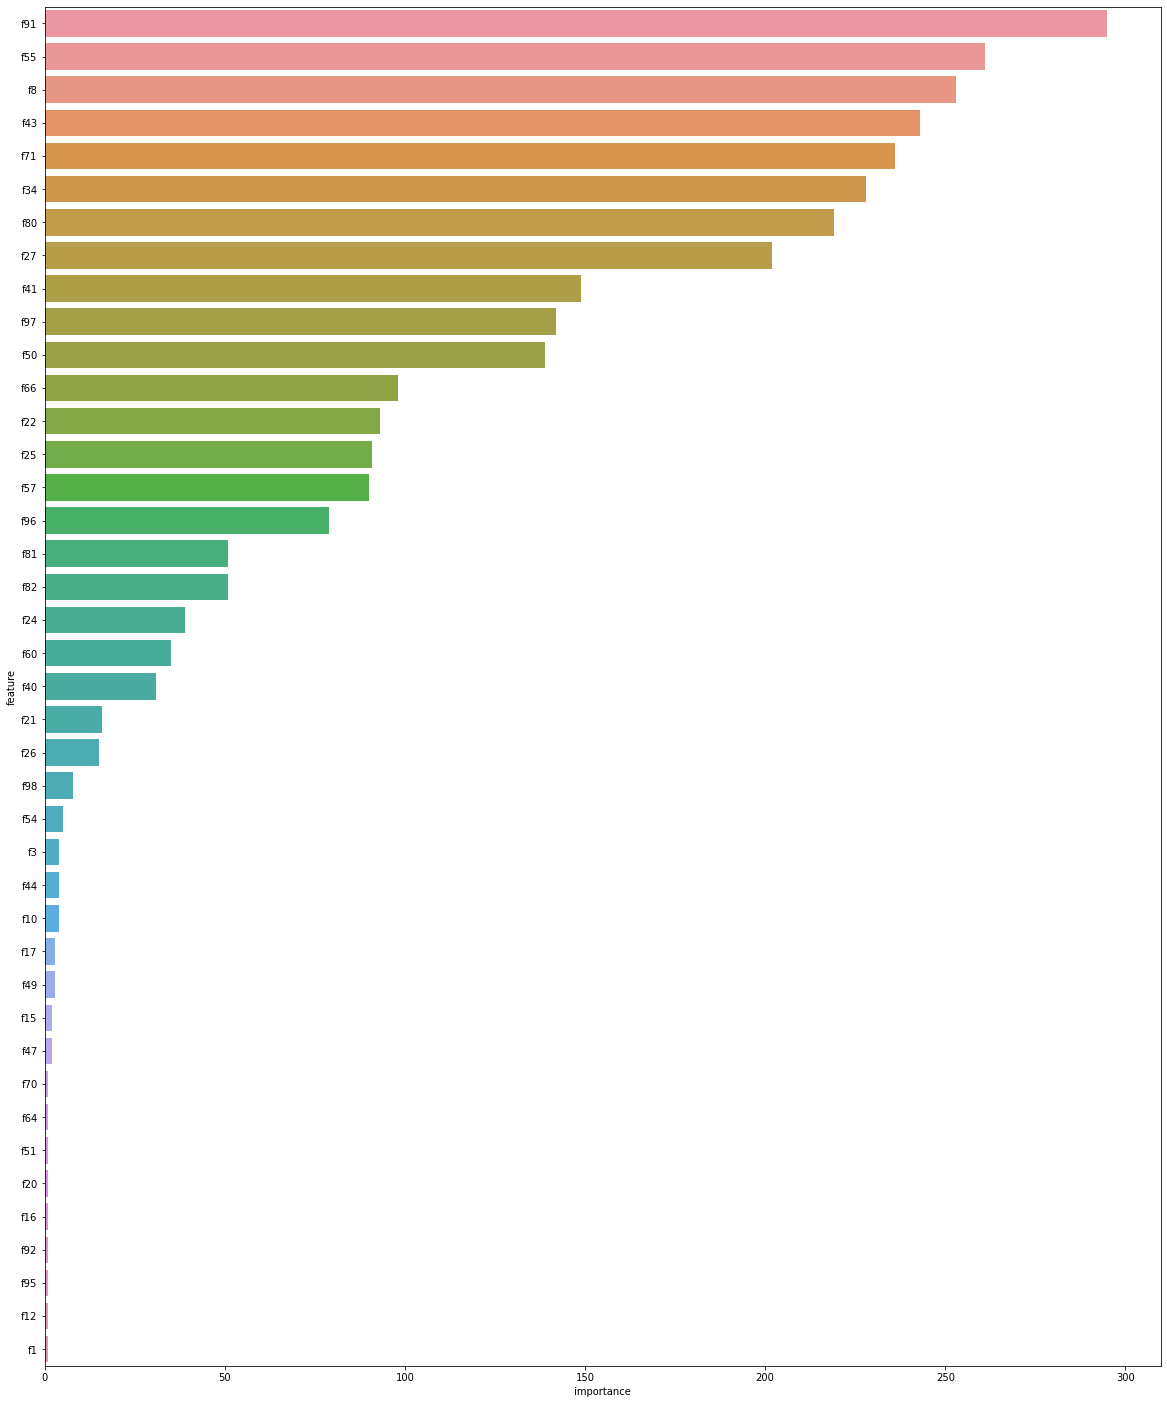

In [24]:
feature_impt=pd.DataFrame(list(best_xgb_model.get_booster().get_fscore().items()),
columns=['feature','importance']).sort_values('importance', ascending=False)
feature_impt.sort_values(by=['importance'],inplace=True,ascending=False)
plt.figure(figsize = (20,25))
sns.barplot(x=feature_impt['importance'],y=feature_impt['feature'],data=feature_impt);

In [25]:
submission = pd.DataFrame()
submission['id'] = df_test['id']
submission['target'] = np.mean(test_preds_xgb, axis = 0)

In [26]:
submission.to_csv('submission', index=False)

### Implementing CATBoost Classifier

Uncomment the following lines to implement CATBoost model.

In [27]:
#from sklearn.model_selection import StratifiedKFold
#from sklearn.metrics import roc_auc_score

#import catboost as catb

#def catb_objective(trial):
#    params = {
#        'iterations' : trial.suggest_int("iterations", 50,100),
#        'learning_rate': trial.suggest_float("learning_rate", 1e-3, 0.25),
#        'depth': trial.suggest_int("depth", 3, 12),
#        'boosting_type': 'Plain',
#        'objective': 'CrossEntropy',
#        'random_seed': 42,
#        'eval_metric' : 'AUC',
#        'bootstrap_type': 'Bernoulli',
#        'logging_level': None,
#        'verbose':-1
#    }
    
#    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.3, random_state = 42)
    
#    model = catb.CatBoostClassifier(**params)
#    model.fit(X_train, y_train,
#              eval_set = [(X_val, y_val)],
#              early_stopping_rounds = 100,
#              verbose = 0
#            )
#    pred_val = model.predict(X_val)
    
#    return roc_auc_score(y_val, pred_val)

In [28]:
#sampler = TPESampler(seed = 42)
#study = optuna.create_study(study_name = 'catb_hpo',direction = 'maximize',sampler = sampler)

#study.optimize(catb_objective, n_trials = 10)

In [29]:
#catbparams = study.best_params

In [30]:
#RANDOM_SEED = 42
#n_splits = 5
#skf = StratifiedKFold(n_splits = n_splits, shuffle = True, random_state = RANDOM_SEED)

#test_preds_catb = []
#mean_auc = 0

#model = catb.CatBoostClassifier(**catbparams)
#best_catb_model = None
#best_roc_score_catb = 0

#for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#    X_train, X_val = X.loc[train_idx], X.loc[val_idx]
#    y_train, y_val = y.loc[train_idx], y.loc[val_idx]
    
#    model.fit(X_train, y_train,
#             verbose = 0,
#             eval_set = [(X_val, y_val)],
#             early_stopping_rounds = 100)
    
#    y_pred = model.predict(X_val)
#    score = roc_auc_score(y_val, y_pred)
#    mean_auc += score
    
    
#    if score>best_roc_score_catb:
#        best_roc_score_catb = score
#        best_catb_model = model
    
#    print(f"Fold {fold}'s score: {score}")
        
#    test_preds_catb.append(model.predict(x_test))

#print("==========================================")
#print(f"Mean auc of all folds: {mean_auc / n_splits}")

In [31]:
#feature_impt=pd.DataFrame()
#feature_impt['features']=best_catb_model.feature_name_
#feature_impt['importance']=best_catb_model.feature_importances_

#feature_impt.sort_values(by=['importance'],inplace=True,ascending=False)
#plt.figure(figsize = (20,25))
#sns.barplot(y=feature_impt['features'],data=feature_impt);

In [32]:
#final_catb = pd.DataFrame()
#final_catb['id'] = df_test['id']
#final_catb['target'] = np.mean(test_preds_catb, axis = 0)